In [ ]:
!pip install gymnasium stable-baselines3 shimmy --quiet

import gymnasium as gym
from gymnasium import spaces
import numpy as np

class CircularRacingEnv(gym.Env):
    """Custom 2D Circular Racing Track Environment for Google Colab"""
    metadata = {"render_modes": ["ansi"]}

    def __init__(self):
        super(CircularRacingEnv, self).__init__()

        # Action Space: 5 discrete keyboard-style inputs
        # 0: Coast, 1: Turn Left, 2: Turn Right, 3: Accelerate, 4: Brake
        self.action_space = spaces.Discrete(5)

        # Observation Space: 5 raycasts + 1 velocity = 6 float values
        # We cap the maximum laser distance reading at 50 meters
        self.observation_space = spaces.Box(
            low=0.0, high=50.0, shape=(6,), dtype=np.float32
        )

        # Track Geometry Constants (Perfect Circle)
        self.TRACK_RADIUS = 100.0
        self.TRACK_WIDTH = 20.0
        self.INNER_RADIUS = self.TRACK_RADIUS - (self.TRACK_WIDTH / 2.0) # 90m
        self.OUTER_RADIUS = self.TRACK_RADIUS + (self.TRACK_WIDTH / 2.0) # 110m

        # Physics Constants
        self.DT = 0.1 # Time step size
        self.MAX_SPEED = 15.0

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        # Spawn the car on the starting line (X=100, Y=0) facing straight up (pi/2 radians)
        self.x = self.TRACK_RADIUS
        self.y = 0.0
        self.theta = np.pi / 2.0
        self.v = 0.0
        self.steps_taken = 0

        return self._get_obs(), {}

    def _get_obs(self):
        """Simulates the 5 Lidar laser beams measuring distance to the walls"""
        # Laser angles relative to car's heading
        ray_angles = [-np.pi/2, -np.pi/4, 0.0, np.pi/4, np.pi/2]
        distances = []

        for angle in ray_angles:
            global_angle = self.theta + angle

            # Simple vector estimation: find distance along the ray until it exits track bounds
            # We check step-by-step up to 50 meters out
            found_wall = False
            for d in range(1, 51):
                check_x = self.x + d * np.cos(global_angle)
                check_y = self.y + d * np.sin(global_angle)
                dist_from_center = np.sqrt(check_x**2 + check_y**2)

                if dist_from_center < self.INNER_RADIUS or dist_from_center > self.OUTER_RADIUS:
                    distances.append(float(d))
                    found_wall = True
                    break
            if not found_wall:
                distances.append(50.0) # Clear view up to max sensor range

        # Combine the 5 laser distances and current velocity into one observation array
        distances.append(self.v)
        return np.array(distances, dtype=np.float32)

    def step(self, action):
        self.steps_taken += 1

        # 1. Handle Actions (Update heading and velocity)
        if action == 1:   # Turn Left
            self.theta += 0.1
        elif action == 2: # Turn Right
            self.theta -= 0.1
        elif action == 3: # Accelerate
            self.v = min(self.v + 1.0, self.MAX_SPEED)
        elif action == 4: # Brake
            self.v = max(self.v - 1.0, 0.0)

        # 2. Update Position using Trigonometry
        self.x += self.v * np.cos(self.theta) * self.DT
        self.y += self.v * np.sin(self.theta) * self.DT

        # 3. Check for Crash or Timeout Conditions
        car_dist_from_center = np.sqrt(self.x**2 + self.y**2)
        crashed = car_dist_from_center < self.INNER_RADIUS or car_dist_from_center > self.OUTER_RADIUS
        timeout = self.steps_taken >= 500 # Cap episodes at 500 steps so they don't run forever

        terminated = crashed
        truncated = timeout


        # REWARD = SPEED
        reward = float(self.v)

        if crashed:
            reward = -10.0

        return self._get_obs(), reward, terminated, truncated, {}

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 6.9 MB/s eta 0:00:00


In [ ]:
from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy

# 1. Instantiate the environment
env = CircularRacingEnv()

# 2. Initialize a PPO Agent
# We use a simple Multi-Layer Perceptron (MlpPolicy) since our inputs are flat arrays
model = PPO("MlpPolicy", env, verbose=1, learning_rate=0.0003)

# 3. Train the agent
print("--- Training the Agent on the Flawed Reward Function ---")
model.learn(total_timesteps=50000)

# 4. Evaluate how well it drives
mean_reward, std_reward = evaluate_policy(model, env, n_eval_episodes=5, render=False)
print(f"\nMean Reward after training: {mean_reward:.2f}")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


--- Training the Agent on the Flawed Reward Function ---


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 131      |
|    ep_rew_mean     | 352      |
| time/              |          |
|    fps             | 542      |
|    iterations      | 1        |
|    time_elapsed    | 3        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 119         |
|    ep_rew_mean          | 424         |
| time/                   |             |
|    fps                  | 539         |
|    iterations           | 2           |
|    time_elapsed         | 7           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.012241964 |
|    clip_fraction        | 0.223       |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.6        |
|    explained_variance   | -0.00281    |
|    learning_rate        | 0.

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/evaluation.py:71: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(



Mean Reward after training: 7395.00


In [ ]:
obs, info = env.reset()
total_reward = 0
print("--- Simulating a Post-Training Episode ---")

for step in range(100):
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    total_reward += reward

    # Print the car's speed and its 3 center laser distances (Left, Center, Right)
    print(f"Step {step} | Action: {action} | Speed: {obs[5]:.1f} | Lidar (Left: {obs[1]:.1f}, Center: {obs[2]:.1f}, Right: {obs[3]:.1f}) | Reward: {reward:.1f}")

    if terminated or truncated:
        print(f"--- Episode ended! Reason: {'Crashed!' if terminated else 'Timeout!'} Total Reward: {total_reward:.1f} ---")
        break

--- Simulating a Post-Training Episode ---
Step 0 | Action: 3 | Speed: 1.0 | Lidar (Left: 14.0, Center: 46.0, Right: 16.0) | Reward: 1.0
Step 1 | Action: 3 | Speed: 2.0 | Lidar (Left: 14.0, Center: 46.0, Right: 16.0) | Reward: 2.0
Step 2 | Action: 3 | Speed: 3.0 | Lidar (Left: 14.0, Center: 46.0, Right: 16.0) | Reward: 3.0
Step 3 | Action: 3 | Speed: 4.0 | Lidar (Left: 14.0, Center: 45.0, Right: 16.0) | Reward: 4.0
Step 4 | Action: 3 | Speed: 5.0 | Lidar (Left: 14.0, Center: 45.0, Right: 16.0) | Reward: 5.0
Step 5 | Action: 3 | Speed: 6.0 | Lidar (Left: 14.0, Center: 44.0, Right: 16.0) | Reward: 6.0
Step 6 | Action: 3 | Speed: 7.0 | Lidar (Left: 14.0, Center: 44.0, Right: 16.0) | Reward: 7.0
Step 7 | Action: 3 | Speed: 8.0 | Lidar (Left: 14.0, Center: 43.0, Right: 16.0) | Reward: 8.0
Step 8 | Action: 3 | Speed: 9.0 | Lidar (Left: 13.0, Center: 42.0, Right: 17.0) | Reward: 9.0
Step 9 | Action: 3 | Speed: 10.0 | Lidar (Left: 13.0, Center: 41.0, Right: 17.0) | Reward: 10.0
Step 10 | Actio

The above simulation does not work well, and instead just oscillates frantically between the track borders. to optimize this, we increase the penalty score deduction drastically.

In [ ]:
class OptimizedRacingEnv(CircularRacingEnv):
    """Upgraded Environment with an Engineering-Grade Reward Function"""

    def step(self, action):
        self.steps_taken += 1

        # 1. Store previous action to penalize rapid twitching if necessary
        # Handle inputs
        if action == 1:   self.theta += 0.1  # Turn Left
        elif action == 2: self.theta -= 0.1  # Turn Right
        elif action == 3: self.v = min(self.v + 1.0, self.MAX_SPEED)
        elif action == 4: self.v = max(self.v - 1.0, 0.0)

        # 2. Physics Update
        self.x += self.v * np.cos(self.theta) * self.DT
        self.y += self.v * np.sin(self.theta) * self.DT

        # 3. Geometric calculations
        car_dist_from_center = np.sqrt(self.x**2 + self.y**2)
        crashed = car_dist_from_center < self.INNER_RADIUS or car_dist_from_center > self.OUTER_RADIUS
        timeout = self.steps_taken >= 500

        terminated = crashed
        truncated = timeout

        # 4. FIXED REWARD DESIGN (Distance-from-Center Penalty Matrix)
        # Base reward component: reward forward velocity
        reward = float(self.v)

        # Distance component: deviation from the perfect center line (100.0m)
        distance_from_centerline = abs(car_dist_from_center - self.TRACK_RADIUS)

        # Apply a scaling penalty for drifting off-center
        reward -= distance_from_centerline * 1.5

        # Catastrophic crash penalty
        if crashed:
            reward = -250.0

        return self._get_obs(), reward, terminated, truncated, {}

In [ ]:
import matplotlib.pyplot as plt
from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy

# 1. Instantiate our optimized environment
opt_env = OptimizedRacingEnv()

# 2. Setup the PPO model
opt_model = PPO("MlpPolicy", opt_env, verbose=0, learning_rate=0.0003)

# 3. Custom training loop to record the learning progress
steps_history = []
rewards_history = []

print("--- Training the Optimized Agent (Tracking Progression) ---")
total_training_steps = 60000
eval_frequency = 5000

for current_step in range(0, total_training_steps, eval_frequency):
    # Train for a chunk of steps
    opt_model.learn(total_timesteps=eval_frequency, reset_num_timesteps=False)

    # Evaluate performance
    mean_reward, _ = evaluate_policy(opt_model, opt_env, n_eval_episodes=5)

    steps_history.append(current_step + eval_frequency)
    rewards_history.append(mean_reward)
    print(f"Total Steps: {current_step + eval_frequency} | Mean Evaluation Reward: {mean_reward:.2f}")

print("\nTraining complete!")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


--- Training the Optimized Agent (Tracking Progression) ---


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/evaluation.py:71: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


Total Steps: 5000 | Mean Evaluation Reward: 4014.55
Total Steps: 10000 | Mean Evaluation Reward: 6693.58
Total Steps: 15000 | Mean Evaluation Reward: 6977.98
Total Steps: 20000 | Mean Evaluation Reward: 7163.67
Total Steps: 25000 | Mean Evaluation Reward: 7168.14
Total Steps: 30000 | Mean Evaluation Reward: 7352.85
Total Steps: 35000 | Mean Evaluation Reward: 7353.00
Total Steps: 40000 | Mean Evaluation Reward: 7352.64
Total Steps: 45000 | Mean Evaluation Reward: 7352.45
Total Steps: 50000 | Mean Evaluation Reward: 7352.69
Total Steps: 55000 | Mean Evaluation Reward: 7352.69
Total Steps: 60000 | Mean Evaluation Reward: 7352.45

Training complete!


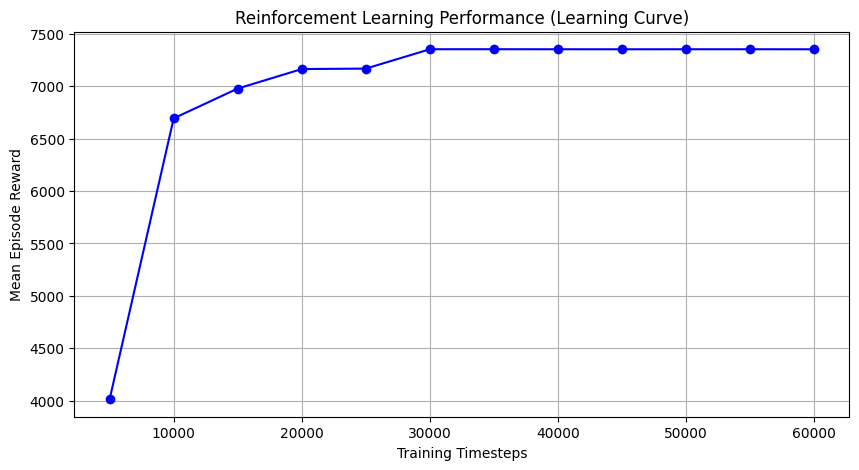

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(steps_history, rewards_history, marker='o', linestyle='-', color='b')
plt.title('Reinforcement Learning Performance (Learning Curve)')
plt.xlabel('Training Timesteps')
plt.ylabel('Mean Episode Reward')
plt.grid(True)
plt.savefig('learning_curve.png') # Saves the image to your Colab directory
plt.show()

In [ ]:
obs, info = opt_env.reset()
total_reward = 0
print("--- Simulating the Optimized Agent ---")

for step in range(50): # Let's look at the first 50 steps
    action, _states = opt_model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = opt_env.step(action)
    total_reward += reward

    # Calculate current distance from center line for logging
    # The last element in obs is velocity, elements 0-4 are lidar rays
    print(f"Step {step:02d} | Action: {action} | Speed: {obs[5]:.1f} | Lidar Center: {obs[2]:.1f} | Step Reward: {reward:.2f}")

    if terminated or truncated:
        break
print(f"--- Episode finished! Total Reward for 50 steps: {total_reward:.2f} ---")

--- Simulating the Optimized Agent ---
Step 00 | Action: 3 | Speed: 1.0 | Lidar Center: 46.0 | Step Reward: 1.00
Step 01 | Action: 3 | Speed: 2.0 | Lidar Center: 46.0 | Step Reward: 2.00
Step 02 | Action: 3 | Speed: 3.0 | Lidar Center: 46.0 | Step Reward: 3.00
Step 03 | Action: 3 | Speed: 4.0 | Lidar Center: 45.0 | Step Reward: 3.99
Step 04 | Action: 3 | Speed: 5.0 | Lidar Center: 45.0 | Step Reward: 4.98
Step 05 | Action: 3 | Speed: 6.0 | Lidar Center: 44.0 | Step Reward: 5.97
Step 06 | Action: 3 | Speed: 7.0 | Lidar Center: 44.0 | Step Reward: 6.94
Step 07 | Action: 3 | Speed: 8.0 | Lidar Center: 43.0 | Step Reward: 7.90
Step 08 | Action: 3 | Speed: 9.0 | Lidar Center: 42.0 | Step Reward: 8.85
Step 09 | Action: 3 | Speed: 10.0 | Lidar Center: 41.0 | Step Reward: 9.77
Step 10 | Action: 3 | Speed: 11.0 | Lidar Center: 40.0 | Step Reward: 10.67
Step 11 | Action: 3 | Speed: 12.0 | Lidar Center: 39.0 | Step Reward: 11.54
Step 12 | Action: 1 | Speed: 12.0 | Lidar Center: 47.0 | Step Reward

As we can see now it works much better.
